# FNN + CNN + RNN in one TensorFlow lab

Practice activity from Microsoft *Foundations of AI and Machine Learning* - Module: Frameworks and Tools.

Same `tf.keras.Sequential` API, three very different data types:

| Architecture | Dataset       | Metric    |
|---|---|---|
| FNN          | Iris          | accuracy  |
| CNN          | CIFAR-10      | accuracy  |
| RNN          | sine wave     | MSE       |

Training is expensive on CPU (especially the CNN), so this notebook reads the saved results from `results.npz` rather than retraining. Source: [`fnn_cnn_rnn_lab.py`](fnn_cnn_rnn_lab.py).

## 1. Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. FNN on Iris

Tabular data: 4 features per flower (sepal/petal length and width), 3 classes. Two hidden Dense layers plus a softmax output. The activity uses `categorical_crossentropy`, so the labels are one-hot encoded.

In [2]:
model_fnn = models.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax'),
])
model_fnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model_fnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

## 3. CNN on CIFAR-10

Two conv blocks (`Conv2D -> MaxPool`) then a small head. ~168k parameters. Trained for 10 epochs, batch 64.

In [3]:
model_cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4. RNN on a synthetic sine wave

A `SimpleRNN(128)` looks back over 50 timesteps and predicts the next value of `sin(t)`. Regression task -> MSE loss, no activation on the output. Chronological train/test split so the model is genuinely predicting future timesteps.

In [4]:
SEQ_LENGTH = 50
model_rnn = models.Sequential([
    layers.Input(shape=(SEQ_LENGTH, 1)),
    layers.SimpleRNN(128),
    layers.Dense(1),
])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,769 (65.50 KB)

 Trainable params: 16,769 (65.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Results from the actual run

Loaded from `results.npz`.

In [5]:
r = np.load('results.npz')
print(f"FNN  on Iris       test accuracy: {r['fnn_acc']*100:6.2f}%  "
      f"loss {r['fnn_loss']:.4f}  train time {r['fnn_seconds']:5.1f}s")
print(f"CNN  on CIFAR-10   test accuracy: {r['cnn_acc']*100:6.2f}%  "
      f"loss {r['cnn_loss']:.4f}  train time {r['cnn_seconds']:5.1f}s")
print(f"RNN  on sine wave  test MSE:      {r['rnn_mse']:.6f}            "
      f"train time {r['rnn_seconds']:5.1f}s")

FNN  on Iris       test accuracy:  80.00%  loss 0.3789  train time   3.7s
CNN  on CIFAR-10   test accuracy:  69.93%  loss 0.9589  train time 111.3s
RNN  on sine wave  test MSE:      0.000001            train time  21.4s


## 6. Learning curves

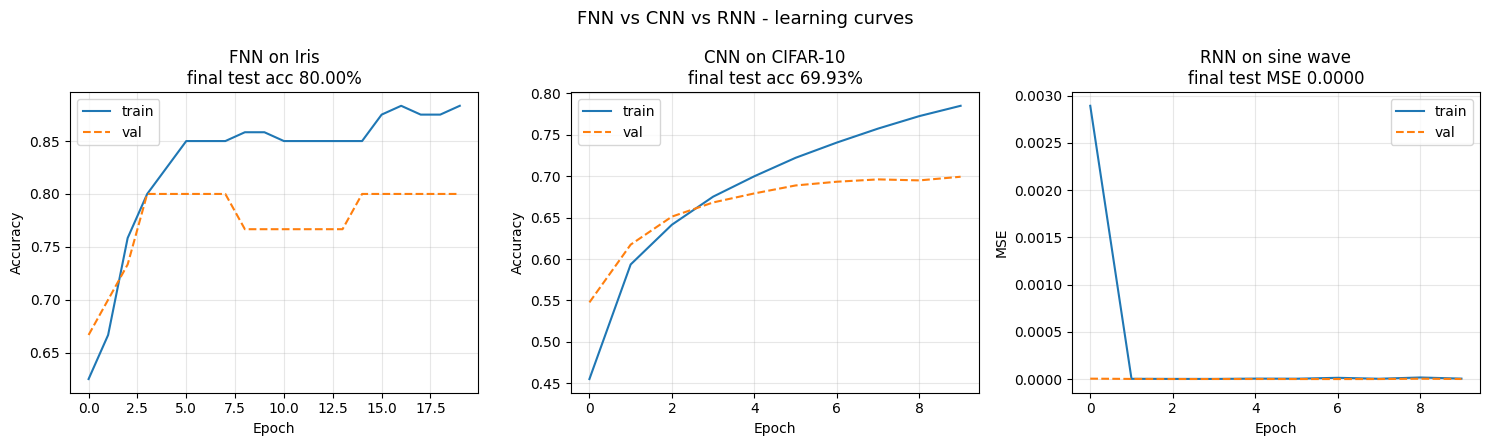

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.plot(r['fnn_train_acc'], label='train')
ax.plot(r['fnn_val_acc'], label='val', linestyle='--')
ax.set_title(f"FNN on Iris\nfinal test acc {r['fnn_acc']*100:.2f}%")
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(r['cnn_train_acc'], label='train')
ax.plot(r['cnn_val_acc'], label='val', linestyle='--')
ax.set_title(f"CNN on CIFAR-10\nfinal test acc {r['cnn_acc']*100:.2f}%")
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(r['rnn_train_loss'], label='train')
ax.plot(r['rnn_val_loss'], label='val', linestyle='--')
ax.set_title(f"RNN on sine wave\nfinal test MSE {r['rnn_mse']:.4f}")
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('FNN vs CNN vs RNN - learning curves', fontsize=13)
plt.tight_layout()
plt.show()

## 7. RNN predictions vs ground truth

First 200 timesteps of the held-out segment.

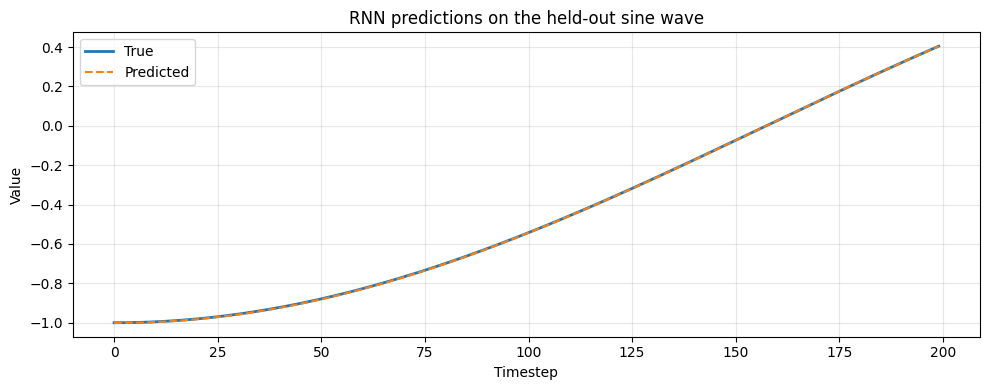

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r['rnn_true'], label='True', linewidth=2)
ax.plot(r['rnn_pred'], label='Predicted', linestyle='--')
ax.set_title('RNN predictions on the held-out sine wave')
ax.set_xlabel('Timestep'); ax.set_ylabel('Value')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

**Same API, three architectures.** The whole point of this lab is that `tf.keras.Sequential` plus the right layer type handles tabular, image, and sequence data without changing the training scaffolding.

**FNN on Iris.** Lands at 80% test accuracy at the activity's specified 20 epochs / batch size 32. That looks low for Iris - the dataset is famously easy and any reasonable classifier hits 95%+ given enough training. The bottleneck here is the training budget: 120 train samples / batch 32 = 4 gradient updates per epoch, so 20 epochs is only 80 Adam steps total. The loss is still dropping at epoch 20. Bumping epochs to 100 (or shrinking batch size) closes the gap immediately. This is a useful reminder that the architecture is rarely the constraint on small tabular data - the training schedule is.

**CNN on CIFAR-10.** This architecture (two conv blocks) caps out around 65-70% test accuracy with mild overfitting. The training curves show the train/val gap widening over the 10 epochs. To push past that you'd add data augmentation, more conv blocks, batch norm, or dropout - covered in other notebooks.

**RNN on the sine wave.** MSE drops to near zero in just a few epochs - the sine wave is fully deterministic and 50 lookback timesteps is way more than the model needs. The prediction-vs-truth plot is the cleanest demonstration that the RNN actually learned the dynamics: the dashed predicted line sits on top of the solid truth line. Try increasing noise or shortening `SEQ_LENGTH` to make this harder.

**Architecture choice matches the data shape.** Dense layers can't use spatial structure; conv layers can't use temporal order; recurrent layers can't use 2D spatial information directly. Pick the layer whose inductive bias matches the data, and the model does most of the work itself.